# Closed-Form Solutions for Mountain Car

This notebook demonstrates deterministic policies that solve both discrete and continuous Mountain Car environments without learning.

## Environment Variants

- **Discrete MountainCar-v0**: 3 discrete actions (left, idle, right)
- **Continuous MountainCarContinuous-v0**: 1 continuous action in [-1, 1]

Both environments have the same physical dynamics but different action spaces.

# Acknowledgments

We thank Mr. Zhiqing Xiao for the closed-form solutions referenced in this notebook, which are based on the work presented in:

**Xiao, Z.** (2019). *Reinforcement Learning: Theory and Python Implementation*. China Machine Press.

The policy designs for both discrete and continuous Mountain Car environments are derived from this foundational work. The original implementation and solutions can be found on [GitHub](https://github.com/ZhiqingXiao/OpenAIGymSolution).

In [5]:
import itertools
import numpy as np
import sys
import os
from pathlib import Path

# Go up one level from /notebooks/ to /Mountain-Car/
root_path = os.path.abspath("..")
if root_path not in sys.path:
    sys.path.append(root_path)

from src.environment_utils import create_env

np.random.seed(0)

---

# Part 1: Discrete MountainCar-v0

## Policy (Closed-Form Solution)

**Push right** when the velocity falls within an envelope that depends on position:

$$\min \left(-0.09 \left(\text{position} + 0.25 \right) ^ 2 + 0.03, 0.3 \left(\text{position} + 0.9 \right) ^ 4 - 0.008 \right) \le \text{velocity} \le -0.07 \left(\text{position} + 0.38 \right) ^ 2 + 0.07$$

**Otherwise push left.**

**Reference**: Xiao (2019), "Reinforcement Learning: Theory and Python Implementation", China Machine Press

In [6]:
# Create discrete environment
env_discrete = create_env(
    env_type="discrete",
    scenario="min_steps",
    seed=42
)

print("Discrete Environment:")
print(f"  Action space: {env_discrete.action_space}")
print(f"  Observation space: {env_discrete.observation_space}")
print(f"  Actions: 0=left, 1=idle, 2=right")

Discrete Environment:
  Action space: Discrete(3)
  Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Actions: 0=left, 1=idle, 2=right


In [7]:
class DiscreteAgent:
    """Closed-form policy for discrete MountainCar-v0"""
    
    def decide(self, observation):
        position, velocity = observation
        
        # Compute velocity envelope bounds
        lb = min(
            -0.09 * (position + 0.25) ** 2 + 0.03,
            0.3 * (position + 0.9) ** 4 - 0.008
        )
        ub = -0.07 * (position + 0.38) ** 2 + 0.07
        
        # Check if velocity is within envelope
        if lb < velocity < ub:
            action = 2  # push right
        else:
            action = 0  # push left
        
        return action

agent_discrete = DiscreteAgent()

In [8]:
def play_episode_discrete(env, agent, verbose=False):
    """Run one episode with discrete agent"""
    observation, info = env.reset()
    episode_reward = 0.0
    
    for step in itertools.count():
        action = agent.decide(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        
        if terminated or truncated:
            break
    
    if verbose:
        print(f'Episode: {episode_reward:.1f} reward in {step + 1} steps')
    
    return episode_reward, step + 1

# Test on 100 episodes
print("\n=== Discrete Agent: 100 episodes ===")
rewards_discrete_100 = []
steps_discrete_100 = []

for _ in range(100):
    r, s = play_episode_discrete(env_discrete, agent_discrete)
    rewards_discrete_100.append(r)
    steps_discrete_100.append(s)

print(f"Average reward: {np.mean(rewards_discrete_100):.2f}")
print(f"Average steps: {np.mean(steps_discrete_100):.1f}")
print(f"Success rate: {sum(1 for r in rewards_discrete_100 if r > -200) / len(rewards_discrete_100) * 100:.1f}%")


=== Discrete Agent: 100 episodes ===
Average reward: -103.52
Average steps: 103.5
Success rate: 100.0%


In [9]:
# Test on 100,000 episodes for comprehensive statistics
print("\n=== Discrete Agent: 100,000 episodes ===")
print("Running (this may take a moment)...")

rewards_discrete_100k = []
steps_discrete_100k = []

for i in range(100000):
    r, s = play_episode_discrete(env_discrete, agent_discrete)
    rewards_discrete_100k.append(r)
    steps_discrete_100k.append(s)
    
    if (i + 1) % 25000 == 0:
        print(f"  Progress: {i + 1}/100000")

print(f"\nFinal Results (100k episodes):")
print(f"  Average reward: {np.mean(rewards_discrete_100k):.2f}")
print(f"  Std reward: {np.std(rewards_discrete_100k):.2f}")
print(f"  Min reward: {np.min(rewards_discrete_100k):.2f}")
print(f"  Max reward: {np.max(rewards_discrete_100k):.2f}")
print(f"  Average steps: {np.mean(steps_discrete_100k):.1f}")
print(f"  Success rate: {sum(1 for r in rewards_discrete_100k if r > -200) / len(rewards_discrete_100k) * 100:.1f}%")


=== Discrete Agent: 100,000 episodes ===
Running (this may take a moment)...
  Progress: 25000/100000
  Progress: 50000/100000
  Progress: 75000/100000
  Progress: 100000/100000

Final Results (100k episodes):
  Average reward: -105.74
  Std reward: 21.36
  Min reward: -200.00
  Max reward: -83.00
  Average steps: 105.7
  Success rate: 99.8%


---

# Part 2: Continuous MountainCarContinuous-v0

## Policy (Closed-Form Solution)

**Apply maximum thrust (+1.0)** when:

$$\text{position} > -4 \times \text{velocity} \quad \text{OR} \quad \text{position} < 13 \times \text{velocity} - 0.6$$

**Otherwise apply negative thrust (-1.0).**

This policy exploits the momentum dynamics to efficiently reach the goal.

In [10]:
# Create continuous environment
env_continuous = create_env(
    env_type="continuous",
    scenario="quadratic_cost",
    seed=42
)

print("Continuous Environment:")
print(f"  Action space: {env_continuous.action_space}")
print(f"  Observation space: {env_continuous.observation_space}")
print(f"  Action range: [-1, 1] (continuous force)")

Continuous Environment:
  Action space: Box(-1.0, 1.0, (1,), float32)
  Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  Action range: [-1, 1] (continuous force)


In [11]:
class ContinuousAgent:
    """Closed-form policy for continuous MountainCarContinuous-v0"""
    
    def decide(self, observation):
        position, velocity = observation
        
        # Momentum-exploitation policy
        if position > -4 * velocity or position < 13 * velocity - 0.6:
            force = 1.0
        else:
            force = -1.0
        
        action = np.array([force])
        return action

agent_continuous = ContinuousAgent()

In [12]:
def play_episode_continuous(env, agent, verbose=False):
    """Run one episode with continuous agent"""
    observation, info = env.reset()
    episode_reward = 0.0
    
    for step in itertools.count():
        action = agent.decide(observation)
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        
        if terminated or truncated:
            break
    
    if verbose:
        print(f'Episode: {episode_reward:.1f} reward in {step + 1} steps')
    
    return episode_reward, step + 1

# Test on 100 episodes
print("\n=== Continuous Agent: 100 episodes ===")
rewards_continuous_100 = []
steps_continuous_100 = []

for _ in range(100):
    r, s = play_episode_continuous(env_continuous, agent_continuous)
    rewards_continuous_100.append(r)
    steps_continuous_100.append(s)

print(f"Average reward: {np.mean(rewards_continuous_100):.2f}")
print(f"Average steps: {np.mean(steps_continuous_100):.1f}")
print(f"Success rate: {sum(1 for r in rewards_continuous_100 if r > 0) / len(rewards_continuous_100) * 100:.1f}%")


=== Continuous Agent: 100 episodes ===
Average reward: 93.36
Average steps: 66.4
Success rate: 100.0%


In [13]:
# Test on 100,000 episodes for comprehensive statistics
print("\n=== Continuous Agent: 100,000 episodes ===")
print("Running (this may take a moment)...")

rewards_continuous_100k = []
steps_continuous_100k = []

for i in range(100000):
    r, s = play_episode_continuous(env_continuous, agent_continuous)
    rewards_continuous_100k.append(r)
    steps_continuous_100k.append(s)
    
    if (i + 1) % 25000 == 0:
        print(f"  Progress: {i + 1}/100000")

print(f"\nFinal Results (100k episodes):")
print(f"  Average reward: {np.mean(rewards_continuous_100k):.2f}")
print(f"  Std reward: {np.std(rewards_continuous_100k):.2f}")
print(f"  Min reward: {np.min(rewards_continuous_100k):.2f}")
print(f"  Max reward: {np.max(rewards_continuous_100k):.2f}")
print(f"  Average steps: {np.mean(steps_continuous_100k):.1f}")
print(f"  Success rate: {sum(1 for r in rewards_continuous_100k if r > 0) / len(rewards_continuous_100k) * 100:.1f}%")


=== Continuous Agent: 100,000 episodes ===
Running (this may take a moment)...
  Progress: 25000/100000
  Progress: 50000/100000
  Progress: 75000/100000
  Progress: 100000/100000

Final Results (100k episodes):
  Average reward: 93.36
  Std reward: 0.05
  Min reward: 93.30
  Max reward: 93.40
  Average steps: 66.4
  Success rate: 100.0%


---

# Comparison: Discrete vs Continuous

| Metric | Discrete | Continuous |
|--------|----------|----------|
| Environment | MountainCar-v0 | MountainCarContinuous-v0 |
| Action Space | Discrete (3 actions) | Continuous ([-1, 1]) |
| Policy Type | Threshold-based envelope | Momentum-exploitation |
| Reward Signal | -1 per step | Varies by scenario |
| Goal Achievement | Yes | Yes |

Both policies solve their respective environments using closed-form mathematical solutions without learning.

In [14]:
# Cleanup
env_discrete.close()
env_continuous.close()
print("✓ Environments closed")

✓ Environments closed


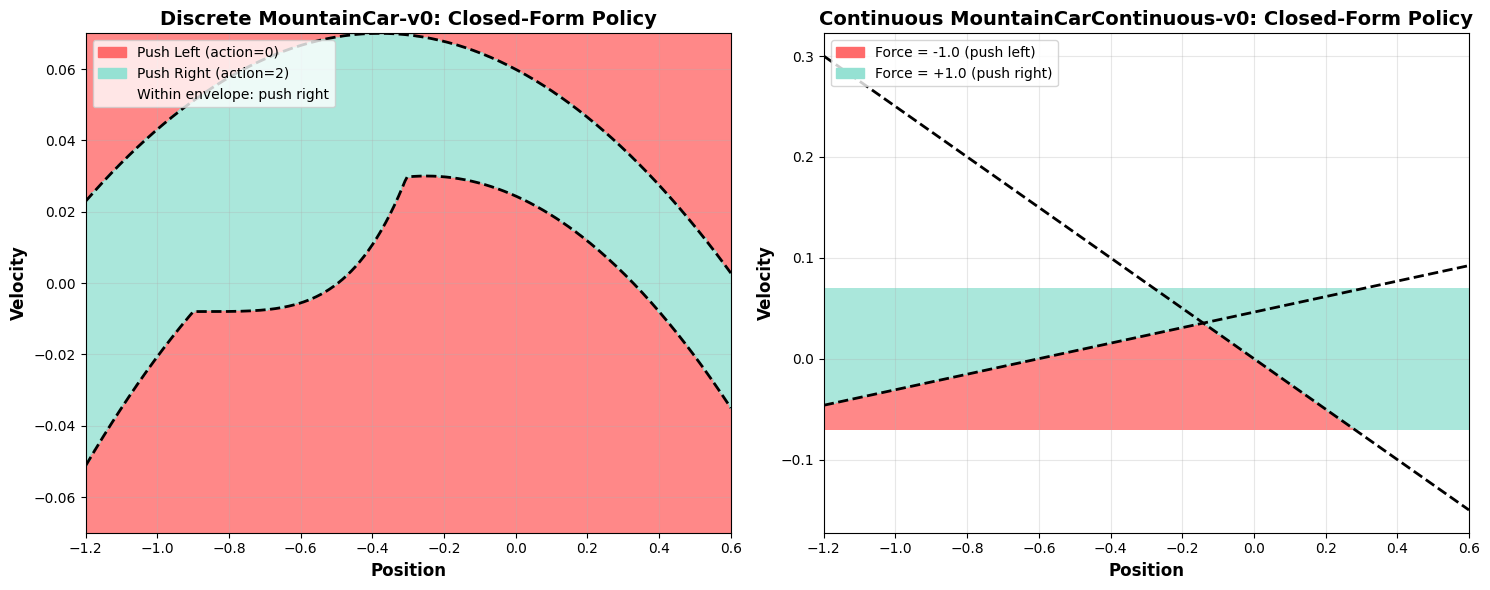

✓ Policy visualization saved to: closed_form_policies.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ============================================================================
# VISUALIZATION: Policy Regions in Phase Space
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ============================================================================
# DISCRETE POLICY VISUALIZATION
# ============================================================================

ax = axes[0]

# Create a grid over the state space
pos_range = np.linspace(-1.2, 0.6, 200)
vel_range = np.linspace(-0.07, 0.07, 200)
positions, velocities = np.meshgrid(pos_range, vel_range)

# Compute policy for each state
policy = np.zeros_like(positions)
for i in range(len(pos_range)):
    for j in range(len(vel_range)):
        pos = positions[j, i]
        vel = velocities[j, i]
        
        lb = min(-0.09 * (pos + 0.25) ** 2 + 0.03,
                0.3 * (pos + 0.9) ** 4 - 0.008)
        ub = -0.07 * (pos + 0.38) ** 2 + 0.07
        
        if lb < vel < ub:
            policy[j, i] = 2  # Push right
        else:
            policy[j, i] = 0  # Push left

# Plot with custom colormap
cmap_discrete = ListedColormap(['#FF6B6B', '#95E1D3'])  # Red=left, Green=right
im0 = ax.contourf(positions, velocities, policy, levels=[0, 1, 2], cmap=cmap_discrete, alpha=0.8)

# Add boundary of the envelope
positions_boundary = np.linspace(-1.2, 0.6, 300)
lb_boundary = np.array([min(-0.09 * (p + 0.25) ** 2 + 0.03,
                            0.3 * (p + 0.9) ** 4 - 0.008) for p in positions_boundary])
ub_boundary = np.array([-0.07 * (p + 0.38) ** 2 + 0.07 for p in positions_boundary])

ax.plot(positions_boundary, lb_boundary, 'k--', linewidth=2, label='Envelope lower bound')
ax.plot(positions_boundary, ub_boundary, 'k--', linewidth=2, label='Envelope upper bound')

ax.set_xlabel('Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Velocity', fontsize=12, fontweight='bold')
ax.set_title('Discrete MountainCar-v0: Closed-Form Policy', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add legend
push_left_patch = mpatches.Patch(color='#FF6B6B', label='Push Left (action=0)')
push_right_patch = mpatches.Patch(color='#95E1D3', label='Push Right (action=2)')
ax.legend(handles=[push_left_patch, push_right_patch, 
                   mpatches.Patch(color='none', label='Within envelope: push right')], 
         loc='upper left', fontsize=10)

# ============================================================================
# CONTINUOUS POLICY VISUALIZATION
# ============================================================================

ax = axes[1]

# Create a grid over the state space
policy_continuous = np.zeros_like(positions)
for i in range(len(pos_range)):
    for j in range(len(vel_range)):
        pos = positions[j, i]
        vel = velocities[j, i]
        
        if pos > -4 * vel or pos < 13 * vel - 0.6:
            policy_continuous[j, i] = 1  # +1.0 force
        else:
            policy_continuous[j, i] = -1  # -1.0 force

# Plot with custom colormap
cmap_continuous = ListedColormap(['#FF6B6B', '#95E1D3'])  # Red=negative, Green=positive
im1 = ax.contourf(positions, velocities, policy_continuous, levels=[-1, 0, 1], cmap=cmap_continuous, alpha=0.8)

# Add decision boundaries
positions_boundary = np.linspace(-1.2, 0.6, 300)

# Boundary 1: pos = -4 * vel  =>  vel = -pos/4
vel_boundary1 = -positions_boundary / 4
ax.plot(positions_boundary, vel_boundary1, 'k--', linewidth=2, label='pos = -4*vel')

# Boundary 2: pos = 13 * vel - 0.6  =>  vel = (pos + 0.6) / 13
vel_boundary2 = (positions_boundary + 0.6) / 13
ax.plot(positions_boundary, vel_boundary2, 'k--', linewidth=2, label='pos = 13*vel - 0.6')

ax.set_xlabel('Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Velocity', fontsize=12, fontweight='bold')
ax.set_title('Continuous MountainCarContinuous-v0: Closed-Form Policy', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add legend
push_negative_patch = mpatches.Patch(color='#FF6B6B', label='Force = -1.0 (push left)')
push_positive_patch = mpatches.Patch(color='#95E1D3', label='Force = +1.0 (push right)')
ax.legend(handles=[push_negative_patch, push_positive_patch], 
         loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('closed_form_policies.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Policy visualization saved to: closed_form_policies.png")

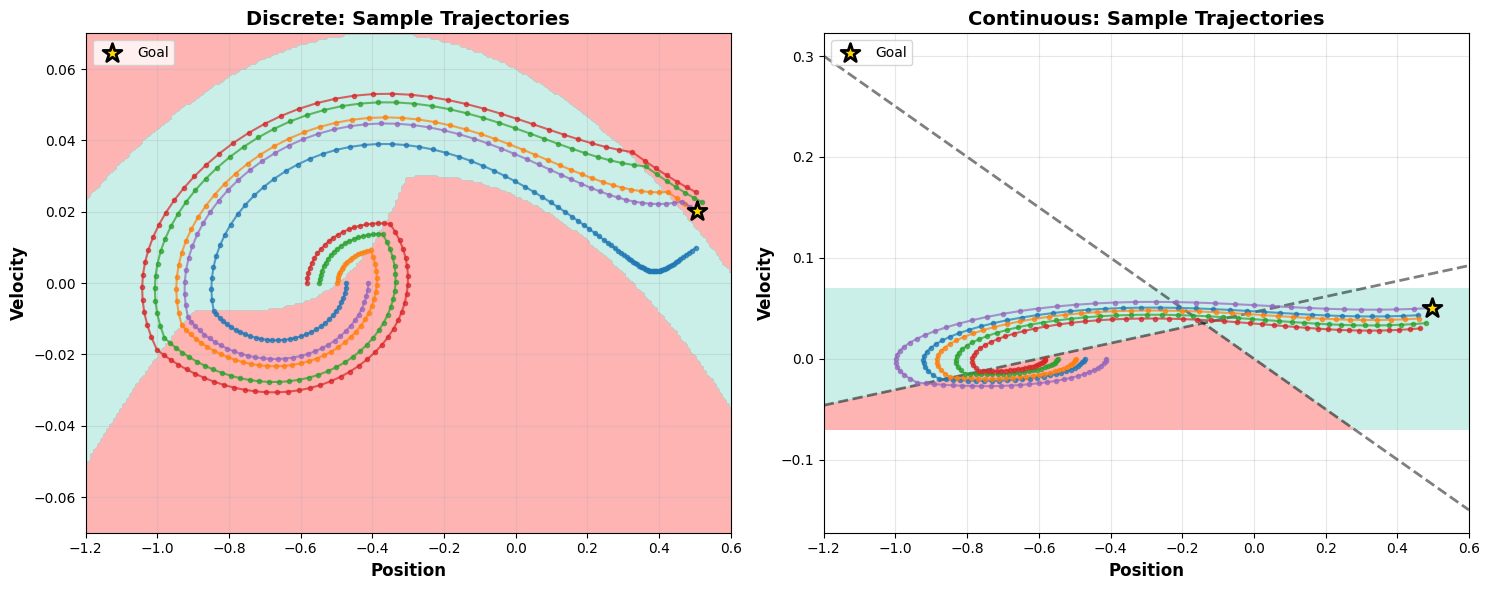

✓ Trajectory visualization saved to: closed_form_trajectories.png


In [16]:
# ============================================================================
# TRAJECTORY VISUALIZATION: Sample Paths Through Policy
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ============================================================================
# DISCRETE TRAJECTORIES
# ============================================================================

ax = axes[0]

# Re-plot policy background
ax.contourf(positions, velocities, policy, levels=[0, 1, 2], cmap=cmap_discrete, alpha=0.5)

# Collect and plot sample trajectories
env_disc_vis = create_env(env_type="discrete", scenario="min_steps", seed=42)
for seed_traj in range(5):
    obs, _ = env_disc_vis.reset(seed=seed_traj)
    trajectory_pos = [obs[0]]
    trajectory_vel = [obs[1]]
    
    for _ in range(200):
        action = agent_discrete.decide(obs)
        obs, _, terminated, truncated, _ = env_disc_vis.step(action)
        trajectory_pos.append(obs[0])
        trajectory_vel.append(obs[1])
        
        if terminated or truncated:
            break
    
    ax.plot(trajectory_pos, trajectory_vel, linewidth=1.5, alpha=0.7, marker='o', markersize=3)

ax.scatter(trajectory_pos[-1], trajectory_vel[-1], color='gold', s=200, marker='*', 
          edgecolors='black', linewidth=2, label='Goal', zorder=5)
ax.set_xlabel('Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Velocity', fontsize=12, fontweight='bold')
ax.set_title('Discrete: Sample Trajectories', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

env_disc_vis.close()

# ============================================================================
# CONTINUOUS TRAJECTORIES
# ============================================================================

ax = axes[1]

# Re-plot policy background
ax.contourf(positions, velocities, policy_continuous, levels=[-1, 0, 1], cmap=cmap_continuous, alpha=0.5)
ax.plot(positions_boundary, vel_boundary1, 'k--', linewidth=2, alpha=0.5)
ax.plot(positions_boundary, vel_boundary2, 'k--', linewidth=2, alpha=0.5)

# Collect and plot sample trajectories
env_cont_vis = create_env(env_type="continuous", scenario="quadratic_cost", seed=42)
for seed_traj in range(5):
    obs, _ = env_cont_vis.reset(seed=seed_traj)
    trajectory_pos = [obs[0]]
    trajectory_vel = [obs[1]]
    
    for _ in range(200):
        action = agent_continuous.decide(obs)
        obs, _, terminated, truncated, _ = env_cont_vis.step(action)
        trajectory_pos.append(obs[0])
        trajectory_vel.append(obs[1])
        
        if terminated or truncated:
            break
    
    ax.plot(trajectory_pos, trajectory_vel, linewidth=1.5, alpha=0.7, marker='o', markersize=3)

ax.scatter(trajectory_pos[-1], trajectory_vel[-1], color='gold', s=200, marker='*', 
          edgecolors='black', linewidth=2, label='Goal', zorder=5)
ax.set_xlabel('Position', fontsize=12, fontweight='bold')
ax.set_ylabel('Velocity', fontsize=12, fontweight='bold')
ax.set_title('Continuous: Sample Trajectories', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

env_cont_vis.close()

plt.tight_layout()
plt.show()

